In [49]:
import subprocess
subprocess.run(["pip", "install", "pandas", "numpy", "matplotlib"])

import pandas as pd
import numpy as np  
import random
import matplotlib.pyplot as plt

df = pd.read_csv("../processed_ml_dataset.csv")
df.head()

,"On a scale of 1–10, how intense is the emotion conveyed by the artwork?",This art piece makes me feel sombre.,This art piece makes me feel content.,This art piece makes me feel calm.,This art piece makes me feel uneasy.,How many prominent colours do you notice in this painting?,How many objects caught your eye in the painting?,How much (in Canadian dollars) would you be willing to pay for this painting?,Painting_Target,room_Living_room,...,sound_violin,sound_peaceful,sound_upbeat,sound_light,sound_classical,sound_happy,sound_wind,sound_sad,sound_gentle,sound_low
0,7.0,3.0,4.0,4.0,2.0,5.0,3.0,0.0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,5.0,4.0,3.0,2.0,1.0,2.0,4.0,0.0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,7.0,4.0,1.0,1.0,4.0,4.0,3.0,5.0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,7.0,4.0,1.0,2.0,4.0,10.0,7.0,0.0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,7.0,3.0,4.0,5.0,3.0,4.0,6.0,300.0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [50]:
X = df.drop(columns=["Painting_Target"]).to_numpy()
y = df["Painting_Target"].astype(int).to_numpy()
y= np.eye(3)[y]

print(X.shape)
print(y.shape)

(1686, 67)
(1686, 3)


In [51]:
np.random.seed(0)

indices = np.random.permutation(X.shape[0])
X = X[indices]
y = y[indices]

split_idx = int(0.8 * X.shape[0])

X_train = X[:split_idx]
y_train = y[:split_idx]

X_val = X[split_idx:]
y_val = y[split_idx:]

mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

std[std == 0] = 1

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)


(1348, 67) (1348, 3)
(338, 67) (338, 3)


In [52]:
def softmax(z):
    """
    Compute the softmax of vector z, or row-wise for a matrix z.
    For numerical stability, subtract the maximum logit value from each
    row prior to exponentiation (see above).

    Parameters:
        `z` - a numpy array of shape (K,) or (N, K)

    Returns: a numpy array with the same shape as `z`, with the softmax
        activation applied to each row of `z`
    """
    if z.ndim == 1:
        m = max(z)
        return np.exp(z - m) / np.sum(np.exp(z - m))
    else:
      m = np.max(z, axis=1, keepdims=True)
      numerator = np.exp(z - m)
      denominator = np.sum(np.exp(z - m), axis = 1, keepdims=True)
      return numerator / denominator

In [53]:
class MLPModel(object):
    def __init__(self, num_features=67, num_hidden1=256, num_hidden2=128, num_hidden3=64, num_classes=3, dropout_rate=0.0):
        """
        Initialize the weights and biases of this four-layer MLP.
        """
        # information about the model architecture
        self.num_features = num_features
        self.num_hidden1 = num_hidden1
        self.num_hidden2 = num_hidden2
        self.num_hidden3 = num_hidden3
        self.num_classes = num_classes
        self.dropout_rate = dropout_rate
        self.training = True

        # weights and biases for the first hidden layer
        self.W1 = np.zeros([num_hidden1, num_features])
        self.b1 = np.zeros([num_hidden1])

        # weights and biases for the second hidden layer
        self.W2 = np.zeros([num_hidden2, num_hidden1])
        self.b2 = np.zeros([num_hidden2])

        # weights and biases for the third hidden layer
        self.W3 = np.zeros([num_hidden3, num_hidden2])
        self.b3 = np.zeros([num_hidden3])

        # weights and biases for the output layer
        self.W4 = np.zeros([num_classes, num_hidden3])
        self.b4 = np.zeros([num_classes])

        # initialize the weights and biases
        self.initializeParams()

        # set all values of intermediate variables (to be used in the
        # forward/backward passes) to None
        self.cleanup()

    def initializeParams(self):
        """
        Initialize the weights and biases of this four-layer MLP to be random.
        This random initialization is necessary to break the symmetry in the
        gradient descent update for our hidden weights and biases. If all our
        weights were initialized to the same value, then their gradients will
        all be the same!
        """
        
        # He initialization works well with ReLU activations.
        self.W1 = np.random.normal(0, np.sqrt(2 / self.num_features), self.W1.shape)
        self.b1 = np.zeros(self.b1.shape)
        self.W2 = np.random.normal(0, np.sqrt(2 / self.num_hidden1), self.W2.shape)
        self.b2 = np.zeros(self.b2.shape)
        self.W3 = np.random.normal(0, np.sqrt(2 / self.num_hidden2), self.W3.shape)
        self.b3 = np.zeros(self.b3.shape)
        self.W4 = np.random.normal(0, np.sqrt(2 / self.num_hidden3), self.W4.shape)
        self.b4 = np.zeros(self.b4.shape)

    def forward(self, X):
        """
        Compute the forward pass to produce prediction for inputs.

        Parameters:
            `X` - A numpy array of shape (N, self.num_features)

        Returns: A numpy array of predictions of shape (N, self.num_classes)
        """
        return do_forward_pass(self, X) # To be implemented below

    def backward(self, ts):
        """
        Compute the backward pass, given the ground-truth, one-hot targets.

        You may assume that the `forward()` method has been called for the
        corresponding input `X`, so that the quantities computed in the
        `forward()` method is accessible.

        Parameters:
            `ts` - A numpy array of shape (N, self.num_classes)
        """
        return do_backward_pass(self, ts) # To be implemented below

    def loss(self, ts):
        """
        Compute the average cross-entropy loss, given the ground-truth, one-hot targets.

        You may assume that the `forward()` method has been called for the
        corresponding input `X`, so that the quantities computed in the
        `forward()` method is accessible.

        Parameters:
            `ts` - A numpy array of shape (N, self.num_classes)
        """
        y_clipped = np.clip(self.y, 1e-12, 1.0)
        return np.sum(-ts * np.log(y_clipped)) / ts.shape[0]

    def update(self, alpha):
        """
        Compute the gradient descent update for the parameters of this model.

        Parameters:
            `alpha` - A number representing the learning rate
        """
        self.W1 = self.W1 - alpha * self.W1_bar
        self.b1 = self.b1 - alpha * self.b1_bar
        self.W2 = self.W2 - alpha * self.W2_bar
        self.b2 = self.b2 - alpha * self.b2_bar
        self.W3 = self.W3 - alpha * self.W3_bar
        self.b3 = self.b3 - alpha * self.b3_bar
        self.W4 = self.W4 - alpha * self.W4_bar
        self.b4 = self.b4 - alpha * self.b4_bar

    def cleanup(self):
        """
        Erase the values of the variables that we use in our computation.
        """
        # To be filled in during the forward pass
        self.N = None # Number of data points in the batch
        self.X = None # The input matrix
        self.m1 = None # Pre-activation value of the first hidden layer
        self.h1 = None # Post-ReLU value of the first hidden layer
        self.m2 = None # Pre-activation value of the second hidden layer
        self.h2 = None # Post-ReLU value of the second hidden layer
        self.m3 = None # Pre-activation value of the third hidden layer
        self.h3 = None # Post-ReLU value of the third hidden layer
        self.dropout_mask1 = None # Dropout mask for the first hidden layer
        self.dropout_mask2 = None # Dropout mask for the second hidden layer
        self.dropout_mask3 = None # Dropout mask for the third hidden layer
        self.z = None # The logit scores (pre-activation output values)
        self.y = None # Class probabilities (post-activation)
        # To be filled in during the backward pass
        self.z_bar = None # The error signal for the logits
        self.W4_bar = None # The error signal for self.W4
        self.b4_bar = None # The error signal for self.b4
        self.h3_bar = None  # The error signal for self.h3
        self.m3_bar = None # The error signal for self.m3
        self.W3_bar = None # The error signal for self.W3
        self.b3_bar = None # The error signal for self.b3
        self.h2_bar = None  # The error signal for self.h2
        self.m2_bar = None # The error signal for self.m2
        self.W2_bar = None # The error signal for self.W2
        self.b2_bar = None # The error signal for self.b2
        self.h1_bar = None  # The error signal for self.h1
        self.m1_bar = None # The error signal for self.m1
        self.W1_bar = None # The error signal for self.W1
        self.b1_bar = None # The error signal for self.b1

In [54]:
def do_forward_pass(model, X):
    """
    Compute the forward pass to produce prediction for inputs.

    This function also keeps some of the intermediate values in
    the neural network computation, to make computing gradients easier.

    For the ReLU activation, you may find the function `np.maximum` helpful

    Parameters:
        `model` - An instance of the class MLPModel
        `X` - A numpy array of shape (N, model.num_features)

    Returns: A numpy array of predictions of shape (N, model.num_classes)
    """
    model.N = X.shape[0]
    model.X = X
    model.m1 = X @ model.W1.T + model.b1
    model.h1 = np.maximum(0, model.m1)
    if model.training and model.dropout_rate > 0:
        keep_prob = 1 - model.dropout_rate
        model.dropout_mask1 = (np.random.rand(*model.h1.shape) < keep_prob) / keep_prob
        model.h1 = model.h1 * model.dropout_mask1
    else:
        model.dropout_mask1 = None
    model.m2 = model.h1 @ model.W2.T + model.b2
    model.h2 = np.maximum(0, model.m2)
    if model.training and model.dropout_rate > 0:
        keep_prob = 1 - model.dropout_rate
        model.dropout_mask2 = (np.random.rand(*model.h2.shape) < keep_prob) / keep_prob
        model.h2 = model.h2 * model.dropout_mask2
    else:
        model.dropout_mask2 = None
    model.m3 = model.h2 @ model.W3.T + model.b3
    model.h3 = np.maximum(0, model.m3)
    if model.training and model.dropout_rate > 0:
        keep_prob = 1 - model.dropout_rate
        model.dropout_mask3 = (np.random.rand(*model.h3.shape) < keep_prob) / keep_prob
        model.h3 = model.h3 * model.dropout_mask3
    else:
        model.dropout_mask3 = None
    model.z = model.h3 @ model.W4.T + model.b4
    model.y = softmax(model.z) # TODO - the class probabilities (post-activation)
    return model.y


In [55]:
def do_backward_pass(model, ts):
    """
    Compute the backward pass, given the ground-truth, one-hot targets.

    You may assume that `model.forward()` has been called for the
    corresponding input `X`, so that the quantities computed in the
    `forward()` method is accessible.

    The member variables you store here will be used in the `update()`
    method. Check that the shapes match what you wrote in Part 2.

    Parameters:
        `model` - An instance of the class MLPModel
        `ts` - A numpy array of shape (N, model.num_classes)
    """
    model.z_bar = (model.y - ts) / model.N
    model.W4_bar = model.z_bar.T @ model.h3
    model.b4_bar = np.sum(model.z_bar, axis=0)
    model.h3_bar = model.z_bar @ model.W4
    if model.dropout_mask3 is not None:
        model.h3_bar = model.h3_bar * model.dropout_mask3
    model.m3_bar = model.h3_bar * (model.m3 > 0)
    model.W3_bar = model.m3_bar.T @ model.h2
    model.b3_bar = np.sum(model.m3_bar, axis=0)
    model.h2_bar = model.m3_bar @ model.W3
    if model.dropout_mask2 is not None:
        model.h2_bar = model.h2_bar * model.dropout_mask2
    model.m2_bar = model.h2_bar * (model.m2 > 0)
    model.W2_bar = model.m2_bar.T @ model.h1
    model.b2_bar = np.sum(model.m2_bar, axis=0)
    model.h1_bar = model.m2_bar @ model.W2
    if model.dropout_mask1 is not None:
        model.h1_bar = model.h1_bar * model.dropout_mask1
    model.m1_bar = model.h1_bar * (model.m1 > 0)
    model.W1_bar = model.m1_bar.T @ model.X
    model.b1_bar = np.sum(model.m1_bar, axis=0)


In [56]:
model = MLPModel(num_features=67, num_hidden1=256, num_hidden2=128, num_hidden3=64, num_classes=3, dropout_rate=0.4)

num_epochs = 3000
learning_rate = 0.0005
batch_size = 64

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    perm = np.random.permutation(X_train.shape[0])
    epoch_loss = 0
    model.training = True

    for i in range(0, X_train.shape[0], batch_size):
        idx = perm[i:i + batch_size]
        model.forward(X_train[idx])
        batch_loss = model.loss(y_train[idx])
        model.backward(y_train[idx])
        model.update(learning_rate)
        epoch_loss += batch_loss * len(idx)

    train_loss = epoch_loss / X_train.shape[0]

    model.training = False
    model.forward(X_val)
    val_loss = model.loss(y_val)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if epoch % 50 == 0:
        print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")


Epoch 0: train_loss=2.7637, val_loss=1.6276
Epoch 50: train_loss=1.1806, val_loss=0.7553
Epoch 100: train_loss=0.9908, val_loss=0.6955
Epoch 150: train_loss=0.8807, val_loss=0.6541
Epoch 200: train_loss=0.8233, val_loss=0.6168
Epoch 250: train_loss=0.8226, val_loss=0.5878
Epoch 300: train_loss=0.7531, val_loss=0.5616
Epoch 350: train_loss=0.7337, val_loss=0.5418
Epoch 400: train_loss=0.6773, val_loss=0.5214
Epoch 450: train_loss=0.6457, val_loss=0.5038
Epoch 500: train_loss=0.6353, val_loss=0.4897
Epoch 550: train_loss=0.6345, val_loss=0.4781
Epoch 600: train_loss=0.5945, val_loss=0.4654
Epoch 650: train_loss=0.5954, val_loss=0.4561
Epoch 700: train_loss=0.5877, val_loss=0.4467
Epoch 750: train_loss=0.5555, val_loss=0.4380
Epoch 800: train_loss=0.6061, val_loss=0.4315
Epoch 850: train_loss=0.5679, val_loss=0.4252
Epoch 900: train_loss=0.5621, val_loss=0.4195
Epoch 950: train_loss=0.5271, val_loss=0.4135
Epoch 1000: train_loss=0.5197, val_loss=0.4083
Epoch 1050: train_loss=0.5095, val_l

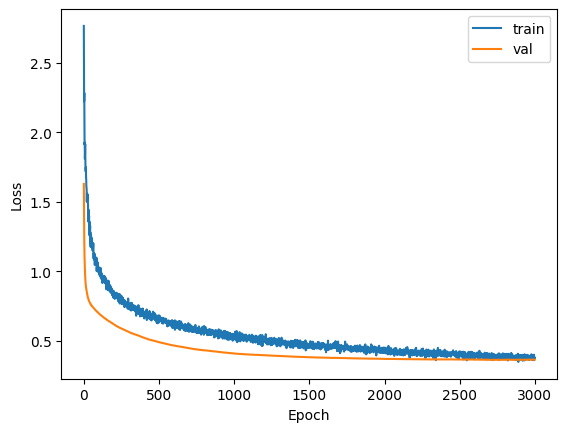

In [57]:
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [58]:
model.training = False

train_probs = model.forward(X_train)
train_preds = np.argmax(train_probs, axis=1)
train_true = np.argmax(y_train, axis=1)
train_accuracy = np.mean(train_preds == train_true)

val_probs = model.forward(X_val)
val_preds = np.argmax(val_probs, axis=1)
val_true = np.argmax(y_val, axis=1)
val_accuracy = np.mean(val_preds == val_true)

print(f"Training accuracy: {train_accuracy * 100:.2f}%")
print(f"Validation accuracy: {val_accuracy * 100:.2f}%")


Training accuracy: 89.47%
Validation accuracy: 85.21%
